# Практична робота 4.5. Використання методів штучного інтелекту для аналізу даних
## Класифікація на наборі даних Kaggle «Titanic — Machine Learning from Disaster»

**Мета:** опанувати базові методи класифікації, виконати повний цикл аналізу даних засобами Python (завантаження → попередня обробка → розподіл → навчання → оцінка) та порівняти ефективність кількох моделей.

**Набір даних:** [Titanic — Machine Learning from Disaster](https://www.kaggle.com/c/titanic), файл `train.csv` (891 пасажир, 12 ознак). Цільова змінна `Survived` (1 — вижив, 0 — загинув).

**Використаний підхід:**
1. Аналіз пропусків і заповнення їх медіаною / модою; видалення малоінформативних ознак.
2. Конструювання ознак (`Title`, `FamilySize`, `IsAlone`) та one-hot encoding категоріальних змінних.
3. Стратифікований розподіл 80:20.
4. Базові моделі: логістична регресія та KNN; додаткові: Random Forest та SVM.
5. Оцінка: accuracy, precision, recall, F1-score, матриця плутанини, ROC-крива (AUC), 5-кратна крос-валідація.

## 1. Завантаження даних

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc,
                             classification_report)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

# train.csv з Kaggle збережено поруч із ноутбуком як titanic.csv.
# Якщо файлу немає — завантажуємо ідентичну публічну копію.
DATA_PATH = "data/titanic.csv"
if not os.path.exists(DATA_PATH):
    DATA_PATH = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

data = pd.read_csv(DATA_PATH)
print("Розмір набору даних:", data.shape)
data.head()

Розмір набору даних: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [3]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 2. Попередня обробка даних
### 2.1. Перевірка пропущених значень

In [4]:
missing = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(1)
pd.DataFrame({"Пропуски": missing, "%": missing_pct})[missing > 0]

,Пропуски,%
Age,177,19.9
Cabin,687,77.1
Embarked,2,0.2


**Стратегія обробки пропусків:**
- `Cabin` — пропущено ~77 % значень, тому ознаку видаляємо (замість неї можна було б використати факт наявності каюти, але для базової моделі це зайве).
- `Age` — ~20 % пропусків; заповнюємо **медіаною** за групою звертання (`Title`: Mr, Mrs, Miss, Master), оскільки вік сильно залежить від неї і медіана стійка до викидів.
- `Embarked` — 2 пропуски; заповнюємо **модою**.

In [5]:
df = data.copy()

# Звертання з імені (Mr, Mrs, Miss, Master ...) — корисна ознака для віку та виживання
df["Title"] = df["Name"].str.extract(r",\s*([^\.]+)\.", expand=False).str.strip()
df["Title"] = df["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
df.loc[~df["Title"].isin(["Mr", "Mrs", "Miss", "Master"]), "Title"] = "Rare"

# Заповнення пропусків
df["Age"] = df["Age"].fillna(df.groupby("Title")["Age"].transform("median"))
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Нові ознаки
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

# Видалення неінформативних / надто розріджених ознак
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

print("Пропусків після обробки:", df.isnull().sum().sum())
df.head()

Пропусків після обробки: 0


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,IsAlone
0,0,3,male,22.0,1,0,7.2500,S,Mr,2,0
1,1,1,female,38.0,1,0,71.2833,C,Mrs,2,0
2,1,3,female,26.0,0,0,7.9250,S,Miss,1,1
3,1,1,female,35.0,1,0,53.1000,S,Mrs,2,0
4,0,3,male,35.0,0,0,8.0500,S,Mr,1,1


### 2.2. Кодування категоріальних змінних (one-hot encoding)

In [6]:
df = pd.get_dummies(df, columns=["Sex", "Embarked", "Title"], drop_first=True, dtype=int)
print("Ознаки після кодування:", list(df.columns))
df.head()

Ознаки після кодування: ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']


,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0,3,22.0,1,0,7.2500,2,0,1,0,1,0,1,0,0
1,1,1,38.0,1,0,71.2833,2,0,0,0,0,0,0,1,0
2,1,3,26.0,0,0,7.9250,1,1,0,0,1,1,0,0,0
3,1,1,35.0,1,0,53.1000,2,0,0,0,1,0,0,1,0
4,0,3,35.0,0,0,8.0500,1,1,1,0,1,0,1,0,0


### 2.3. Розподіл класів у цільовій змінній

Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    61.6 %
1    38.4 %
Name: count, dtype: str


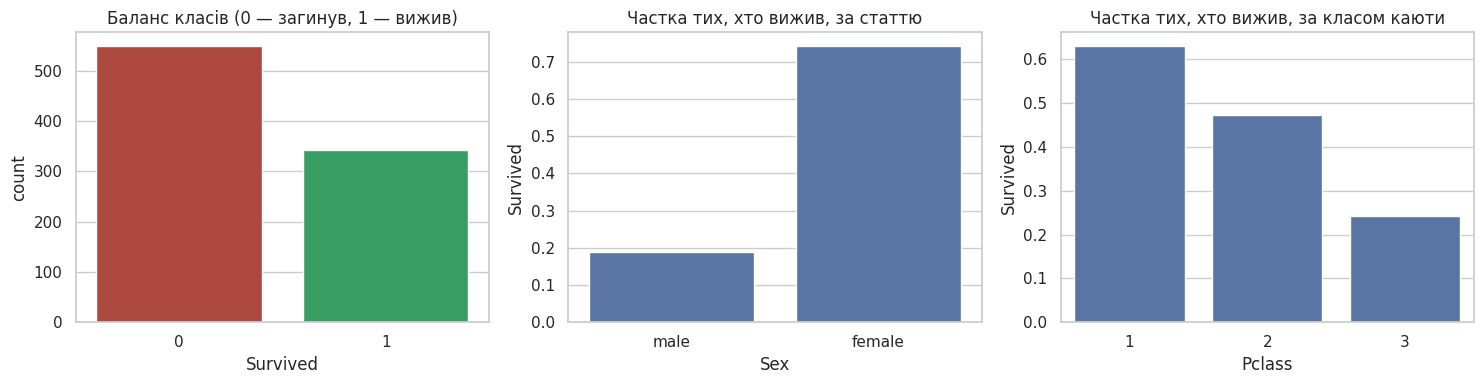

In [7]:
counts = data["Survived"].value_counts().sort_index()
print(counts)
print((counts / counts.sum() * 100).round(1).astype(str) + " %")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(x="Survived", hue="Survived", data=data, ax=axes[0], palette=["#c0392b", "#27ae60"], legend=False)
axes[0].set_title("Баланс класів (0 — загинув, 1 — вижив)")
sns.barplot(x="Sex", y="Survived", data=data, ax=axes[1], errorbar=None)
axes[1].set_title("Частка тих, хто вижив, за статтю")
sns.barplot(x="Pclass", y="Survived", data=data, ax=axes[2], errorbar=None)
axes[2].set_title("Частка тих, хто вижив, за класом каюти")
plt.tight_layout()
plt.show()

Класи **помірно незбалансовані** (≈ 62 % загиблих проти ≈ 38 % тих, хто вижив). Дисбаланс некритичний, тому пересемплювання не застосовуємо, але при розподілі використовуємо **стратифікацію**, а окрім accuracy аналізуємо precision, recall та F1. Графіки показують, що стать і клас каюти — найсильніші чинники виживання.

## 3. Розподіл даних на тренувальний і тестовий набори (80:20)

In [8]:
X = df.drop(columns="Survived")
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f"Тренувальний набір: {X_train.shape[0]} записів")
print(f"Тестовий набір:     {X_test.shape[0]} записів")
print("Частка класу 1 у train/test:", round(y_train.mean(), 3), "/", round(y_test.mean(), 3))

Тренувальний набір: 712 записів
Тестовий набір:     179 записів
Частка класу 1 у train/test: 0.383 / 0.385


## 4. Побудова моделей класифікації
Для логістичної регресії, KNN та SVM ознаки масштабуються `StandardScaler` (ці методи чутливі до масштабу; особливо KNN, що рахує відстані). Масштабування вбудоване в `Pipeline`, щоб параметри нормалізації обчислювались лише на тренувальних даних.

### 4.1. Вибір кількості сусідів k для KNN (крос-валідація)

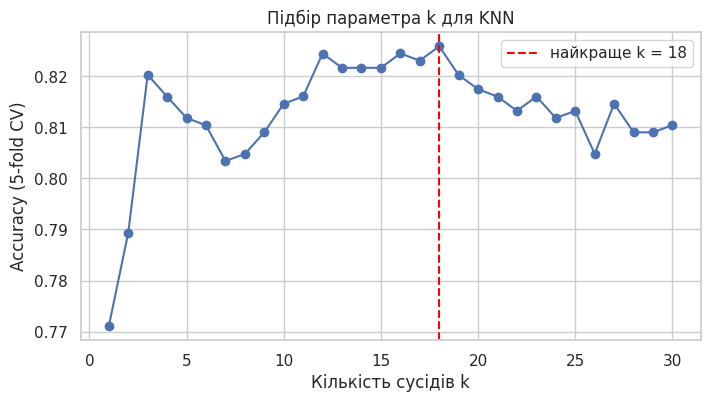

Найкраще k за крос-валідацією: 18


In [9]:
k_range = range(1, 31)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
k_scores = [cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k)),
                           X_train, y_train, cv=cv, scoring="accuracy").mean() for k in k_range]
best_k = list(k_range)[int(np.argmax(k_scores))]

plt.figure(figsize=(8, 4))
plt.plot(k_range, k_scores, marker="o")
plt.axvline(best_k, color="red", linestyle="--", label=f"найкраще k = {best_k}")
plt.xlabel("Кількість сусідів k"); plt.ylabel("Accuracy (5-fold CV)")
plt.title("Підбір параметра k для KNN"); plt.legend(); plt.show()
print("Найкраще k за крос-валідацією:", best_k)

### 4.2. Створення та навчання моделей

In [10]:
models = {
    "Логістична регресія": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    f"KNN (k={best_k})": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=best_k)),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=7, random_state=RANDOM_STATE),
    "SVM (RBF)": make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1.0, probability=True, random_state=RANDOM_STATE)),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"Навчено: {name}")

Навчено: Логістична регресія
Навчено: KNN (k=18)


Навчено: Random Forest
Навчено: SVM (RBF)


## 5. Оцінка моделей
### 5.1. Метрики на тестовому наборі

In [11]:
results, probas, preds = [], {}, {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    preds[name], probas[name] = y_pred, y_prob
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    results.append({
        "Модель": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC AUC": auc(fpr, tpr),
    })

results_df = pd.DataFrame(results).set_index("Модель").round(3)
results_df.style.highlight_max(axis=0, color="#b7e4c7").format("{:.3f}")

,Accuracy,Precision,Recall,F1-score,ROC AUC
Модель,,,,,
Логістична регресія,0.855,0.841,0.768,0.803,0.880
KNN (k=18),0.838,0.857,0.696,0.768,0.862
Random Forest,0.816,0.810,0.681,0.740,0.858
SVM (RBF),0.838,0.823,0.739,0.779,0.848


In [12]:
for name in models:
    print(f"===== {name} =====")
    print(classification_report(y_test, preds[name], target_names=["Загинув", "Вижив"], digits=3))

===== Логістична регресія =====
              precision    recall  f1-score   support

     Загинув      0.862     0.909     0.885       110
       Вижив      0.841     0.768     0.803        69

    accuracy                          0.855       179
   macro avg      0.852     0.839     0.844       179
weighted avg      0.854     0.855     0.853       179

===== KNN (k=18) =====
              precision    recall  f1-score   support

     Загинув      0.829     0.927     0.876       110
       Вижив      0.857     0.696     0.768        69

    accuracy                          0.838       179
   macro avg      0.843     0.811     0.822       179
weighted avg      0.840     0.838     0.834       179

===== Random Forest =====
              precision    recall  f1-score   support

     Загинув      0.818     0.900     0.857       110
       Вижив      0.810     0.681     0.740        69

    accuracy                          0.816       179
   macro avg      0.814     0.791     0.799    

### 5.2. Матриці плутанини

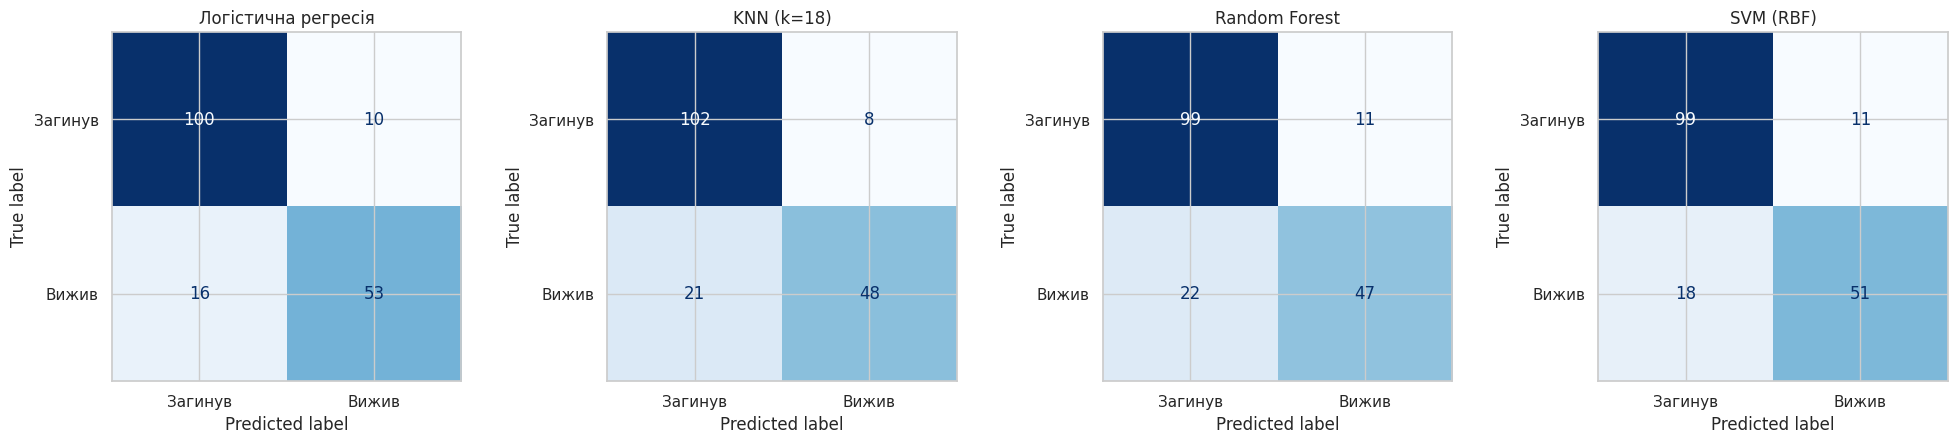

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, name in zip(axes, models):
    cm = confusion_matrix(y_test, preds[name])
    ConfusionMatrixDisplay(cm, display_labels=["Загинув", "Вижив"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

### 5.3. ROC-криві

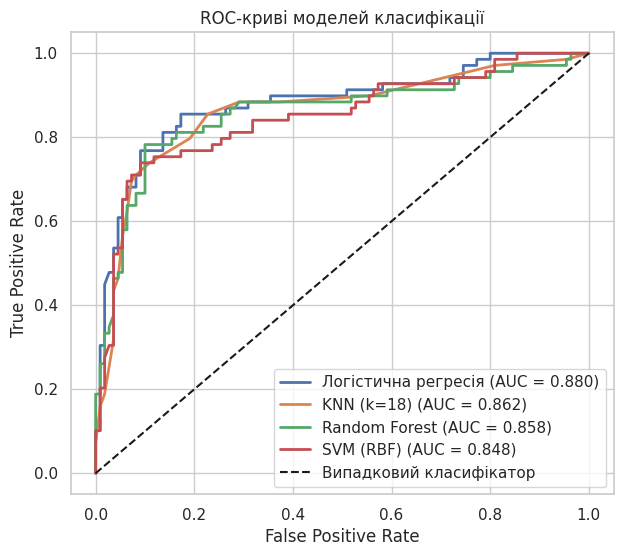

In [14]:
plt.figure(figsize=(7, 6))
for name, y_prob in probas.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc(fpr, tpr):.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Випадковий класифікатор")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC-криві моделей класифікації")
plt.legend(loc="lower right"); plt.show()

## 6. Порівняння моделей
### 6.1. Метрики на тестовому наборі

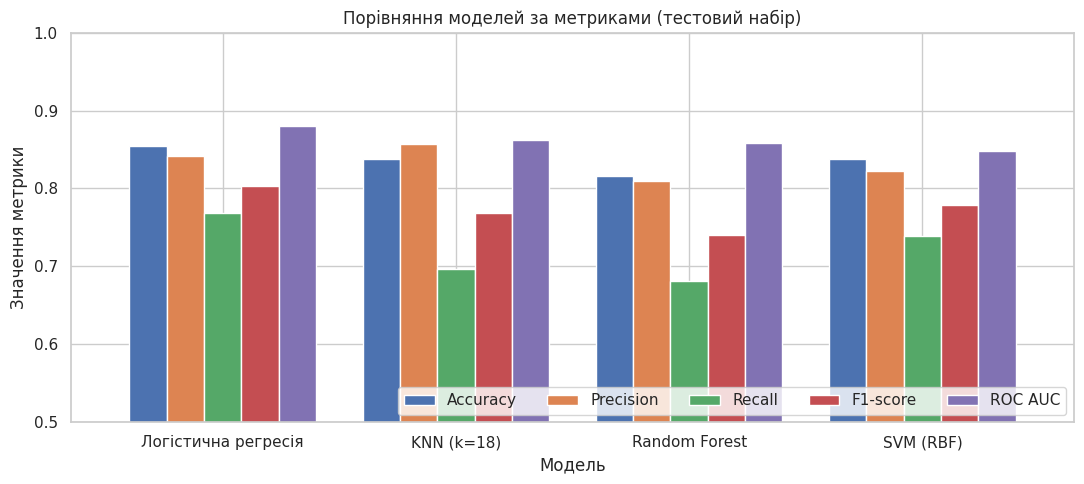

In [15]:
ax = results_df.plot(kind="bar", figsize=(11, 5), rot=0, width=0.8)
ax.set_ylim(0.5, 1.0); ax.set_ylabel("Значення метрики")
ax.set_title("Порівняння моделей за метриками (тестовий набір)")
ax.legend(loc="lower right", ncol=5)
plt.tight_layout(); plt.show()

### 6.2. Стійкість: 5-кратна крос-валідація на тренувальному наборі
Один тестовий набір із 179 записів дає доволі шумну оцінку, тому додатково перевіряємо стабільність моделей крос-валідацією.

In [16]:
cv_rows = []
for name, model in models.items():
    acc = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    f1s = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1")
    cv_rows.append({"Модель": name, "CV Accuracy": f"{acc.mean():.3f} ± {acc.std():.3f}",
                    "CV F1": f"{f1s.mean():.3f} ± {f1s.std():.3f}"})
pd.DataFrame(cv_rows).set_index("Модель")

,CV Accuracy,CV F1
Модель,,
Логістична регресія,0.824 ± 0.027,0.765 ± 0.030
KNN (k=18),0.826 ± 0.030,0.752 ± 0.045
Random Forest,0.817 ± 0.022,0.746 ± 0.033
SVM (RBF),0.827 ± 0.025,0.759 ± 0.037


## 7. Важливість ознак (Random Forest та логістична регресія)

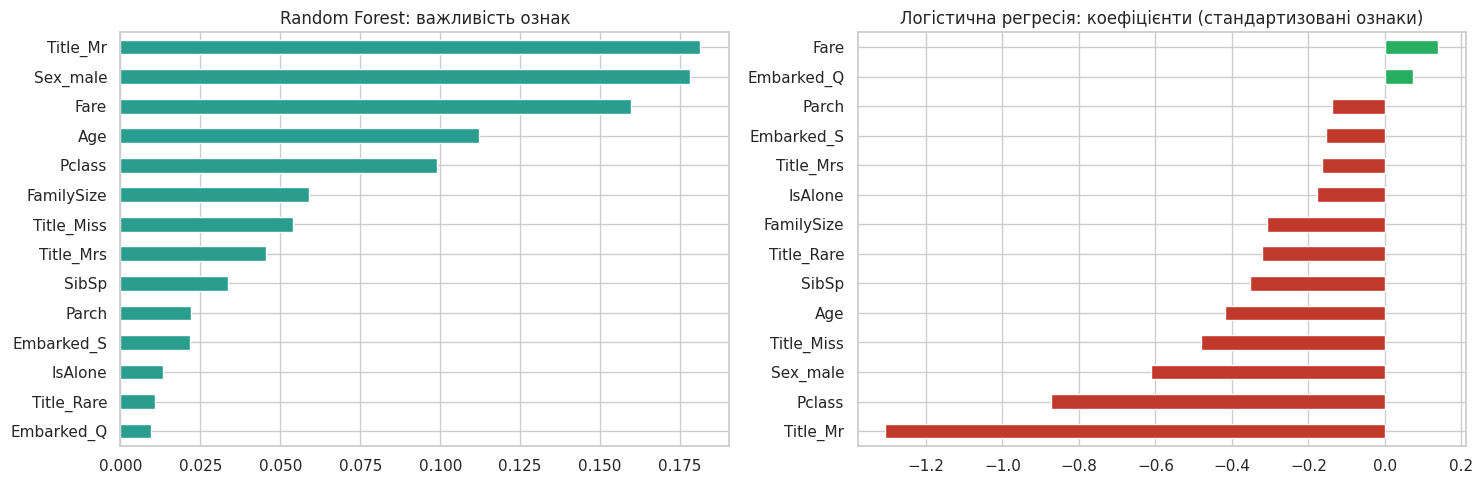

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
imp = pd.Series(models["Random Forest"].feature_importances_, index=X.columns).sort_values()
imp.plot(kind="barh", ax=axes[0], color="#2a9d8f"); axes[0].set_title("Random Forest: важливість ознак")

coef = pd.Series(models["Логістична регресія"][-1].coef_[0], index=X.columns).sort_values()
coef.plot(kind="barh", ax=axes[1], color=np.where(coef > 0, "#27ae60", "#c0392b"))
axes[1].set_title("Логістична регресія: коефіцієнти (стандартизовані ознаки)")
plt.tight_layout(); plt.show()

## 8. Звіт і висновки

### Використаний підхід
Використано навчальну вибірку `train.csv` конкурсу Kaggle «Titanic» (891 запис). Пропуски оброблено так: `Cabin` (77 % пропусків) видалено, `Age` заповнено медіаною в межах групи звертання (`Title`), `Embarked` заповнено модою. Створено додаткові ознаки `Title`, `FamilySize`, `IsAlone`, категоріальні змінні закодовано методом one-hot encoding. Дані розділено 80:20 (712 / 179 записів) зі стратифікацією за цільовою змінною. Навчено чотири класифікатори: логістичну регресію, KNN (k = 18, підібрано 5-кратною крос-валідацією), Random Forest і SVM з RBF-ядром.

### Ключові результати (тестовий набір, 179 пасажирів)

| Модель | Accuracy | Precision | Recall | F1-score | ROC AUC |
|---|---|---|---|---|---|
| **Логістична регресія** | **0.855** | 0.841 | **0.768** | **0.803** | **0.880** |
| KNN (k = 18) | 0.838 | **0.857** | 0.696 | 0.768 | 0.862 |
| Random Forest | 0.816 | 0.810 | 0.681 | 0.740 | 0.858 |
| SVM (RBF) | 0.838 | 0.823 | 0.739 | 0.779 | 0.848 |

За 5-кратною крос-валідацією на тренувальному наборі точність усіх моделей лежить у діапазоні 0.817–0.827 (± 0.02–0.03), тобто різниця між ними статистично невелика.

### Висновки
1. **Найкращий результат на тестовому наборі показала логістична регресія**: accuracy 85.5 %, F1 0.803 і найбільша площа під ROC-кривою (AUC 0.880). Для невеликого табличного набору з добре підготовленими ознаками проста лінійна модель не поступається складнішим методам.
2. **KNN** має найвищу precision (0.857), але найнижчий серед лідерів recall (0.696): модель обережно прогнозує клас «вижив» і пропускає частину тих, хто вижив. Масштабування ознак і підбір k (з 7 до 18) підвищили її accuracy з 0.816 до 0.838.
3. **Додаткові моделі (Random Forest, SVM)** не дали переваги: SVM зрівнявся з KNN за accuracy (0.838) з кращим балансом precision/recall, Random Forest виявився найслабшим на цьому розбитті (0.816). Крос-валідація показує, що всі чотири моделі мають близьку узагальнювальну здатність (~82 %).
4. **Типова помилка всіх моделей — хибнонегативні прогнози** (recall класу «вижив» 0.68–0.77 проти 0.90–0.93 для класу «загинув»). Це наслідок дисбалансу класів 62/38. Якщо важливіше не пропустити тих, хто вижив, варто знизити поріг класифікації або застосувати `class_weight="balanced"`.
5. **Найвпливовіші ознаки**: стать (`Sex_male`), звертання (`Title_Mr`), клас каюти (`Pclass`) і вартість квитка (`Fare`). Це відповідає історичному принципу евакуації «спершу жінки та діти» і перевагам пасажирів першого класу.

**Можливі покращення:** підбір гіперпараметрів через `GridSearchCV`, ознаки з `Cabin` (палуба) і `Ticket`, ансамблі на основі градієнтного бустингу (XGBoost, LightGBM).